In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import unityandnormal as u_n
import os
from datetime import timedelta
from pyextremes import EVA
from pyextremes import plot_threshold_stability

In [11]:
def extremesss(loc, name, thresh, declust):
    f, axs = plt.subplots(1,len(thresh))

    for ax, l, n, th, dec in zip(axs, loc, name, thresh, declust):
        df = pd.read_pickle(l)
        df = df.dropna()
        model = EVA(df['0'])
        model.data.name = n
        # i  = 250
        model.get_extremes(method="POT", threshold=th, r=dec)
        model.fit_model()

        
        model.plot_return_values(alpha=0.95, ax=ax, figsize=(8,5))
        ax.lines[2].set_label(f"Genpareto fit: \nc: {model.distribution.mle_parameters["c"].round(3)} \nshape: {int(model.distribution.mle_parameters["scale"])}")
        ax.lines[0].set_label("CI: \nalpha = 0.95")
        # print(ax.properties)
        ax.legend()
        f.subplots_adjust(wspace=0.5)

        model.plot_extremes(figsize=(13,8))
        # plot_threshold_stability(
        #     df['0'],
        #     return_period=100,
        #     thresholds=np.linspace(th-th/5, th+th/5, 20),
        #     r=dec
        # )
        print(model)
        

    return model

                           Univariate Extreme Value Analysis                            
                                      Source Data                                       
----------------------------------------------------------------------------------------
Data label:        Discharge at Carrascal      Size:                              14,274
Start:                       October 1969      End:                       September 2011
                                     Extreme Values                                     
----------------------------------------------------------------------------------------
Count:                                 75      Extraction method:                    POT
Type:                                high      Threshold:                            360
                                         Model                                          
----------------------------------------------------------------------------------------
Model:               

                           Univariate Extreme Value Analysis                            
                                      Source Data                                       
----------------------------------------------------------------------------------------
Data label:            Discharge at Mainz      Size:                              22,707
Start:                      November 1958      End:                        December 2020
                                     Extreme Values                                     
----------------------------------------------------------------------------------------
Count:                                108      Extraction method:                    POT
Type:                                high      Threshold:                           2970
                                         Model                                          
----------------------------------------------------------------------------------------
Model:               

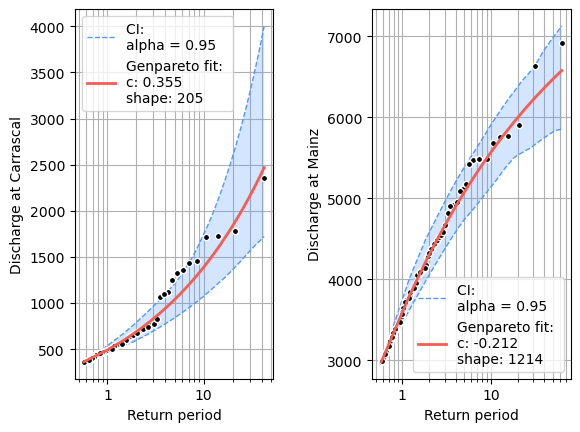

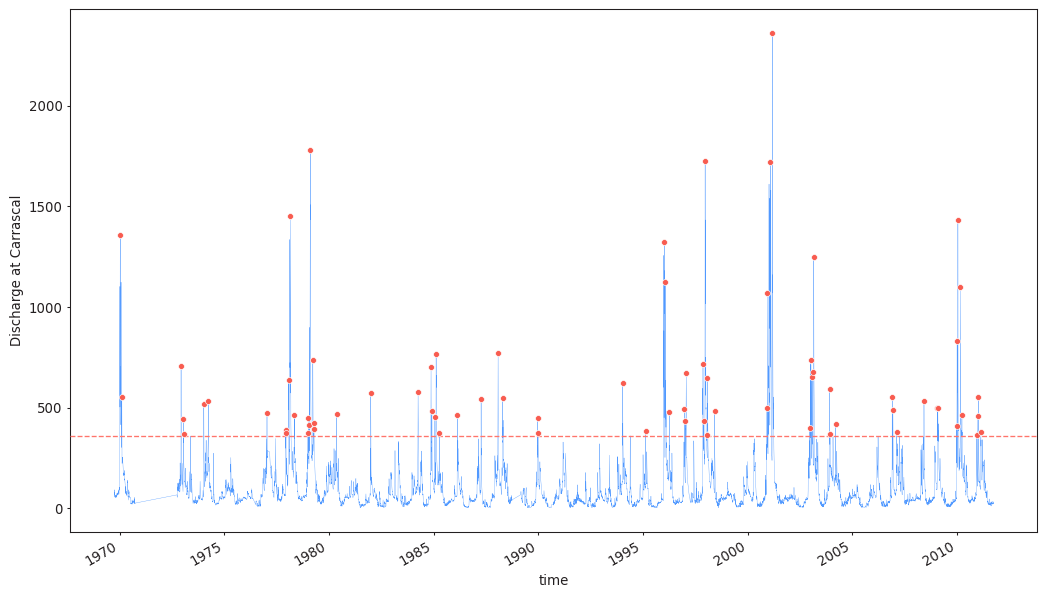

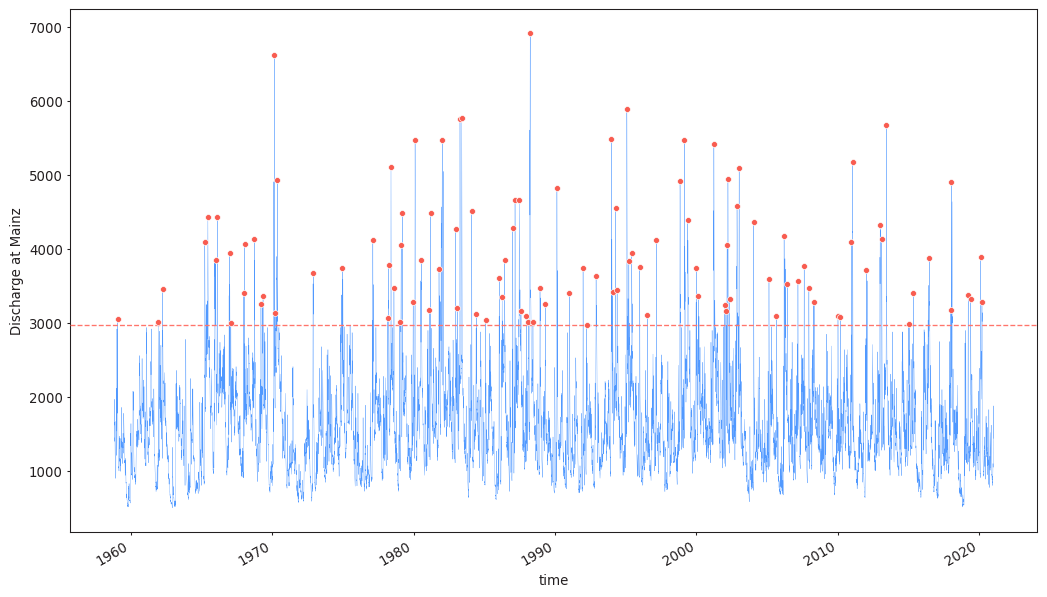

In [ ]:
extremesss(["Data/DueroData.pkl", "Data/RijnData.pkl"], ["Discharge at Toro", "Discharge at Mainz"], [360, 2970], ["48h", "15d"])

In [ ]:
df = pd.read_pickle("Data/DueroData.pkl")
df = df.dropna()
print(df['0'].mean())

df = pd.read_pickle("Data/DueroData.pkl")
df = df.dropna()
print(df['0'].mean())


104.40026632047477


In [110]:
model = EVA(df['0'])
model.data.name = "Discharge at Carrascal"

In [111]:
# plot_threshold_stability(
#     df['0'],
#     return_period=100,
#     thresholds=np.linspace(100, 300, 20),
#     r="48h"
# )

In [112]:
i  = 250

model.get_extremes(method="POT", threshold=i, r="48h")
# plt.figure()
# model.plot_extremes(figsize=(50,5), show_clusters=True)
# plt.figure()
# # plt.subplots
# pd.plotting.autocorrelation_plot(np.array(model.extremes.values)-i)
# plt.title(f"r = {i}, n={model.extremes.shape[0]}")
model.fit_model()


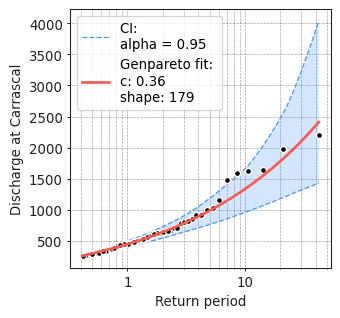

In [113]:
# f, ax = plt.subplots(1,1)
f, ax = model.plot_return_values(alpha=0.95, figsize=(3.5,3.5))
ax.lines[2].set_label(f"Genpareto fit: \nc: {model.distribution.mle_parameters["c"].round(3)} \nshape: {int(model.distribution.mle_parameters["scale"])}")
ax.lines[0].set_label("CI: \nalpha = 0.95")
# print(ax.properties)
ax.legend()

<Axes: xlabel='time'>

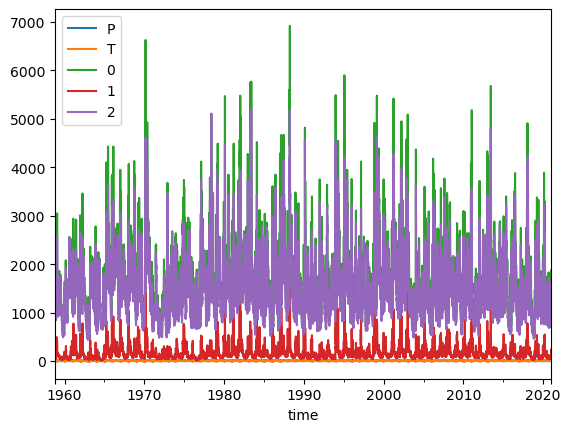

In [114]:
df = pd.read_pickle("Data/RijnData.pkl")
df = df.dropna()
df.plot()


In [102]:
model = EVA(df['0'])
model.data.name = "Discharge at Mainz"

In [103]:
i  = 2970

model.get_extremes(method="POT", threshold=i, r="15d")
# plt.figure()
# model.plot_extremes(figsize=(50,5), show_clusters=True)
# plt.figure()
# pd.plotting.autocorrelation_plot(np.array(model.extremes.values)-i)
# plt.title(f"r = {i}, n={model.extremes.shape[0]}")
model.fit_model()

# plt.legend()

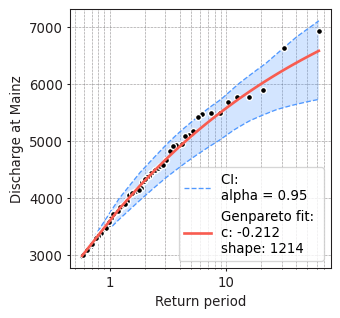

In [104]:
# f, ax = plt.subplots(1,1)
f, ax = model.plot_return_values(alpha=0.95, figsize=(3.5,3.5))
ax.lines[2].set_label(f"Genpareto fit: \nc: {model.distribution.mle_parameters["c"].round(3)} \nshape: {int(model.distribution.mle_parameters["scale"])}")
ax.lines[0].set_label("CI: \nalpha = 0.95")
# print(ax.properties)
ax.legend()

In [105]:
# # for i in range(3,20):
# plt.figure()
# plot_threshold_stability(
#     df['0'],
#     return_period=50,
#     thresholds=np.linspace(2800, 3300, 20),
#     r="15d"
# )